In [25]:
import pandas as pd
import yfinance as yf
from datetime import date
from yfetch import get_stock_history
from time import sleep



In [26]:
symbol = 'AVGO'

ticker = yf.Ticker(symbol)
history = get_stock_history(symbol, interval='1d')


In [27]:
def future_price(expiry: str) -> float:
  calendar_days = (date.fromisoformat(expiry) - date.today()).days
  trading_days = round(calendar_days * 252 / 365)
  sma_days = trading_days
  
  sma = history['Close'].rolling(window=sma_days).mean()
  last_sma = sma.iloc[-1]
  sma_dist = history.Close / sma - 1
  median_dist = sma_dist.median()
  sma_median_change = sma.pct_change(periods=trading_days).median()
  return last_sma * (1 + sma_median_change) * (1 + median_dist)

def call_chain(expiry: str) -> list[tuple[float, float]]:
  chain = ticker.option_chain(expiry)
  calls = chain.calls
  
  # Calculate mid prices
  calls = calls.copy()
  calls['mid'] = (calls['bid'] + calls['ask']) / 2
  calls = calls[calls['mid'] > 0].reset_index(drop=True)
  
  # Filter outliers: call prices should decrease monotonically with strike
  # Flag rows where price doesn't fit the pattern
  result = []
  for i, row in calls.iterrows():
    mid = row['mid']
    # Check neighbors for consistency
    prev_mid = calls.loc[i-1, 'mid'] if i > 0 else None
    next_mid = calls.loc[i+1, 'mid'] if i < len(calls)-1 else None
    
    # Call price should be between neighbors (with tolerance)
    if prev_mid is not None and next_mid is not None:
      expected = (prev_mid + next_mid) / 2
      if abs(mid - expected) > 0.5 * abs(prev_mid - next_mid) + 1:
        continue  # skip outlier
    
    result.append((row['strike'], mid))
  return result

def call_profits(expiry: str) -> pd.DataFrame:
  price = future_price(expiry)
  calls = call_chain(expiry)
  rows = []
  for strike, call_price in calls:
    if call_price <= 0:
      continue
    if strike > price:
      break
    itm = max(0, price - strike)
    profit = max(-1, itm / call_price - 1)
    rows.append({
      'Strike': strike,
      'Call Price': call_price,
      'ITM': itm,
      'Profit': profit,
    })
  return pd.DataFrame(rows)

In [28]:
expiry_profits = {}
rows = []
for expiry in ticker.options:
  sleep(1)  # to avoid hitting yfinance rate limits
  days = (date.fromisoformat(expiry) - date.today()).days
  df = call_profits(expiry)
  expiry_profits[expiry] = df
  mp = df.Profit.max()
  max_profit = mp * 365 / days
  print(f'{expiry}: {mp:+10.2%} {max_profit:+10.2%} p.a.')
  rows.append({
    'Expiry': date.fromisoformat(expiry),
    'MaxProfit': max_profit,
  })
df = pd.DataFrame(rows)


2026-01-02:     +0.79%    +57.93% p.a.
2026-01-09:     -2.89%    -87.96% p.a.
2026-01-16:    +46.25%   +888.55% p.a.
2026-01-23:   +100.16%  +1406.16% p.a.
2026-01-30:   +128.93%  +1426.08% p.a.
2026-02-20:    +83.51%   +564.44% p.a.
2026-03-20:    +94.85%   +422.22% p.a.
2026-04-17:   +142.90%   +474.18% p.a.
2026-05-15:   +143.17%   +378.69% p.a.
2026-06-18:   +148.48%   +315.09% p.a.
2026-07-17:   +189.32%   +343.79% p.a.
2026-08-21:   +188.44%   +291.45% p.a.
2026-09-18:   +187.41%   +259.11% p.a.
2026-12-18:   +308.01%   +316.69% p.a.
2027-01-15:   +373.95%   +356.37% p.a.
2027-06-17:   +632.73%   +430.87% p.a.
2027-12-17:   +826.47%   +419.56% p.a.
2028-01-21:   +917.88%   +444.33% p.a.


Max profit call:
Expiry       2026-01-30
MaxProfit     14.260819
Name: 4, dtype: object


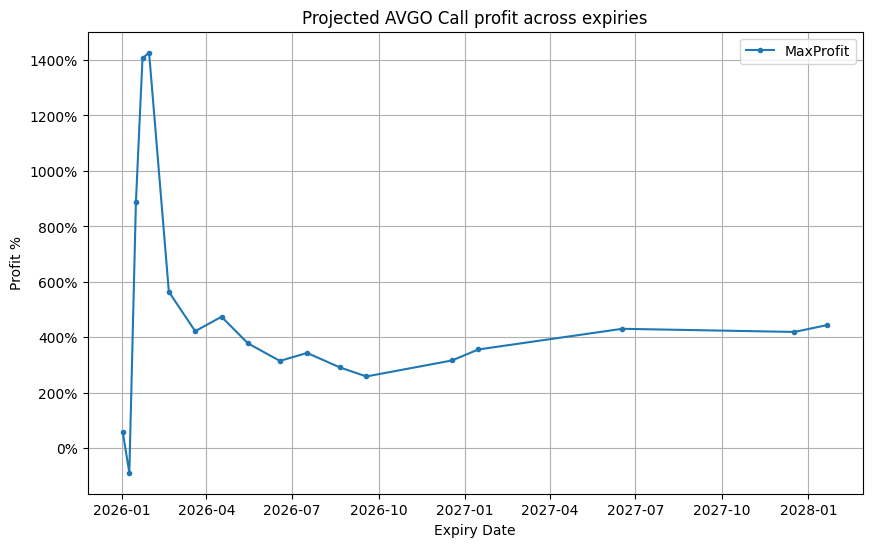

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

max_profit_row = df.loc[df['MaxProfit'].idxmax()]
print(f"Max profit call:")
print(max_profit_row)

ax = df.plot(
  x='Expiry', 
  y='MaxProfit', 
  kind='line', 
  marker='.', 
  title=f'Projected {symbol} Call profit across expiries', 
  xlabel='Expiry Date', 
  ylabel='Profit %', 
  figsize=(10,6),
  grid=True)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.show()

Max profit strike on 2026-01-30:
Strike        360.000000
Call Price     14.425000
ITM            33.023648
Profit          1.289334
Name: 28, dtype: float64


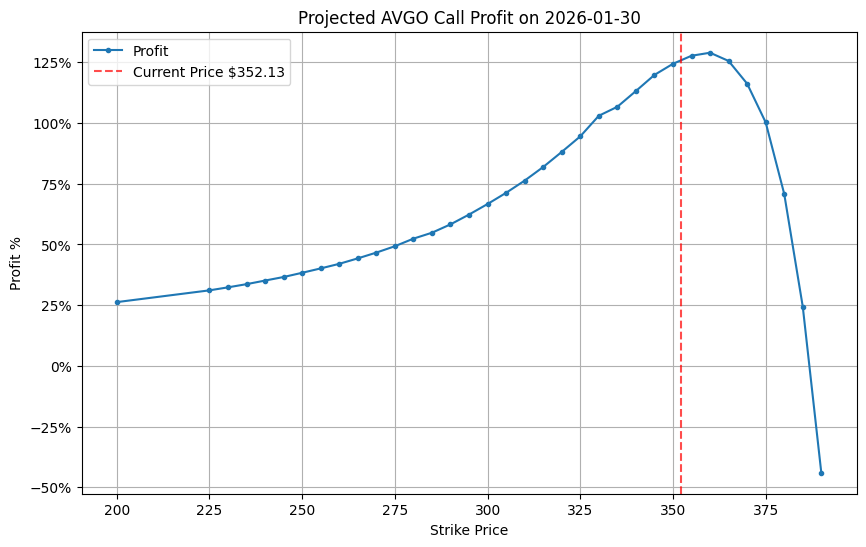

In [33]:
expiry = max_profit_row['Expiry'].isoformat()
# expiry = '2026-01-30'
stock_price=ticker.info['regularMarketPrice']
df = expiry_profits[expiry]

ax = df.plot(
  x='Strike', 
  y='Profit', 
  kind='line', 
  marker='.', 
  title=f'Projected {symbol} Call Profit on {expiry}', 
  xlabel='Strike Price', 
  ylabel='Profit %', 
  figsize=(10,6),
  grid=True)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axvline(x=stock_price, color='red', linestyle='--', alpha=0.7, label=f'Current Price ${stock_price:.2f}')
ax.legend()

print(f"Max profit strike on {expiry}:")
print(df.loc[df['Profit'].idxmax()])


In [31]:
display(df)

,Strike,Call Price,ITM,Profit
0,200.0,152.900,193.023648,0.262418
1,225.0,128.175,168.023648,0.310893
2,230.0,123.200,163.023648,0.323244
3,235.0,118.250,158.023648,0.336352
4,240.0,113.250,153.023648,0.351202
5,245.0,108.375,148.023648,0.365847
6,250.0,103.400,143.023648,0.383207
7,255.0,98.500,138.023648,0.401255
8,260.0,93.675,133.023648,0.420055
9,265.0,88.750,128.023648,0.442520
